# Mini Project 1 - The Movie Database

## Data Source & attribution:

Source:  Data was retrieved from [The Movie Database](https://www.themoviedb.org/)   

## Questions I want to answer:
1. What makes a movie popular?
2. Does having a higher budget lead to higher revenue?
3. Does having a higher budget lead to higher ratings?
4. Does popularity equal higher ratings?
5. Do newer movies outperform older movies?
6. Are movies getting longer over time?

## Importing Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import scipy.stats as stats

## Getting the data

In [2]:
# Getting my access token
with open("access_token.txt", "r") as f:
    access_token = f.read().strip()

#Necessary headers for the API request
headers = {
    "accept": "application/json",
    "Authorization": f"Bearer {access_token}"
}

In [3]:
#What one API request looks like
url = "https://api.themoviedb.org/3/discover/movie?include_adult=false&include_video=false&language=en-US&page=1&sort_by=vote_count.desc"
response = requests.get(url, headers=headers)

In [4]:
#Checking response status code
response.status_code

200

In [5]:
#Checking the api call. It's only gives one page of 20 movies
data = response.json()
data

{'page': 1,
 'results': [{'adult': False,
   'backdrop_path': '/2ssWTSVklAEc98frZUQhgtGHx7s.jpg',
   'genre_ids': [12, 18, 878],
   'id': 157336,
   'title': 'Interstellar',
   'original_language': 'en',
   'original_title': 'Interstellar',
   'overview': 'The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.',
   'popularity': 59.6559,
   'poster_path': '/yQvGrMoipbRoddT0ZR8tPoR7NfX.jpg',
   'release_date': '2014-11-05',
   'softcore': False,
   'video': False,
   'vote_average': 8.47,
   'vote_count': 39440},
  {'adult': False,
   'backdrop_path': '/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg',
   'genre_ids': [28, 878, 12],
   'id': 27205,
   'title': 'Inception',
   'original_language': 'en',
   'original_title': 'Inception',
   'overview': 'Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offere

In [6]:
#List of movies
all_movies = []

#API request for multiple pages
#100 pages * 20 movies per page = 2000 movies
for page in range(1, 101):   
    url = "https://api.themoviedb.org/3/discover/movie"
    params = {
        "language": "en-US",
        "sort_by": "vote_count.desc",
        "page": page
    }
    
    r = requests.get(url, headers=headers, params=params)
    results = r.json()["results"]
    all_movies.extend(results)

#Putting the movies into a dataframe
df = pd.DataFrame(all_movies)
df.head()

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,False,/2ssWTSVklAEc98frZUQhgtGHx7s.jpg,"[12, 18, 878]",157336,Interstellar,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,/yQvGrMoipbRoddT0ZR8tPoR7NfX.jpg,2014-11-05,False,False,8.470,39440
1,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,"[28, 878, 12]",27205,Inception,en,Inception,"Cobb, a skilled thief who commits corporate es...",37.7947,/xlaY2zyzMfkhk0HSC5VUwzoZPU1.jpg,2010-07-15,False,False,8.400,39047
2,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,"[878, 28, 12]",24428,The Avengers,en,The Avengers,When an unexpected enemy emerges and threatens...,56.9481,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,2012-04-25,False,False,8.004,37341
3,False,/cfT29Im5VDvjE0RpyKOSdCKZal7.jpg,"[28, 80, 53]",155,The Dark Knight,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,33.2276,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,2008-07-16,False,False,8.528,35529
4,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"[878, 28, 12]",19995,Avatar,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",35.3880,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,2009-12-16,False,False,7.602,33812


In [7]:
#Getting genre dictionary
url = "https://api.themoviedb.org/3/genre/movie/list?language=en"
response = requests.get(url, headers=headers)
genre_dict = {item['id']: item['name'] for item in response.json()['genres']}

In [8]:
genre_dict

{28: 'Action',
 12: 'Adventure',
 16: 'Animation',
 35: 'Comedy',
 80: 'Crime',
 99: 'Documentary',
 18: 'Drama',
 10751: 'Family',
 14: 'Fantasy',
 36: 'History',
 27: 'Horror',
 10402: 'Music',
 9648: 'Mystery',
 10749: 'Romance',
 878: 'Science Fiction',
 10770: 'TV Movie',
 53: 'Thriller',
 10752: 'War',
 37: 'Western'}

In [9]:
#What's in our general dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              2000 non-null   bool   
 1   backdrop_path      2000 non-null   object 
 2   genre_ids          2000 non-null   object 
 3   id                 2000 non-null   int64  
 4   title              2000 non-null   object 
 5   original_language  2000 non-null   object 
 6   original_title     2000 non-null   object 
 7   overview           2000 non-null   object 
 8   popularity         2000 non-null   float64
 9   poster_path        2000 non-null   object 
 10  release_date       2000 non-null   object 
 11  softcore           2000 non-null   bool   
 12  video              2000 non-null   bool   
 13  vote_average       2000 non-null   float64
 14  vote_count         2000 non-null   int64  
dtypes: bool(3), float64(2), int64(2), object(8)
memory usage: 193.5+ KB


In [10]:
#Getting more details for the top 100
movies_with_detail = []
for movie_id in df['id'][:100]:
    url = f'https://api.themoviedb.org/3/movie/{movie_id}'
    response = requests.get(url, headers=headers)
    movies_with_detail.append(response.json())
df_with_detail = pd.DataFrame(movies_with_detail)
df_with_detail.info() 

#Saving this dataframe to csv
df_with_detail.to_csv('movie_with_detail.csv',index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  100 non-null    bool   
 1   backdrop_path          100 non-null    object 
 2   belongs_to_collection  72 non-null     object 
 3   budget                 100 non-null    int64  
 4   genres                 100 non-null    object 
 5   homepage               100 non-null    object 
 6   id                     100 non-null    int64  
 7   imdb_id                100 non-null    object 
 8   origin_country         100 non-null    object 
 9   original_language      100 non-null    object 
 10  original_title         100 non-null    object 
 11  overview               100 non-null    object 
 12  popularity             100 non-null    float64
 13  poster_path            100 non-null    object 
 14  production_companies   100 non-null    object 
 15  product

## Data Cleaning

In [11]:
df_clean = df.copy()

In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              2000 non-null   bool   
 1   backdrop_path      2000 non-null   object 
 2   genre_ids          2000 non-null   object 
 3   id                 2000 non-null   int64  
 4   title              2000 non-null   object 
 5   original_language  2000 non-null   object 
 6   original_title     2000 non-null   object 
 7   overview           2000 non-null   object 
 8   popularity         2000 non-null   float64
 9   poster_path        2000 non-null   object 
 10  release_date       2000 non-null   object 
 11  softcore           2000 non-null   bool   
 12  video              2000 non-null   bool   
 13  vote_average       2000 non-null   float64
 14  vote_count         2000 non-null   int64  
dtypes: bool(3), float64(2), int64(2), object(8)
memory usage: 193.5+ KB


In [13]:
df_clean.drop(columns=df_clean.columns[[0,1,9,11,12]], inplace= True)

In [14]:
df_clean.head()

,genre_ids,id,title,original_language,original_title,overview,popularity,release_date,vote_average,vote_count
0,"[12, 18, 878]",157336,Interstellar,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,2014-11-05,8.470,39440
1,"[28, 878, 12]",27205,Inception,en,Inception,"Cobb, a skilled thief who commits corporate es...",37.7947,2010-07-15,8.400,39047
2,"[878, 28, 12]",24428,The Avengers,en,The Avengers,When an unexpected enemy emerges and threatens...,56.9481,2012-04-25,8.004,37341
3,"[28, 80, 53]",155,The Dark Knight,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,33.2276,2008-07-16,8.528,35529
4,"[878, 28, 12]",19995,Avatar,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",35.3880,2009-12-16,7.602,33812


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genre_ids          2000 non-null   object 
 1   id                 2000 non-null   int64  
 2   title              2000 non-null   object 
 3   original_language  2000 non-null   object 
 4   original_title     2000 non-null   object 
 5   overview           2000 non-null   object 
 6   popularity         2000 non-null   float64
 7   release_date       2000 non-null   object 
 8   vote_average       2000 non-null   float64
 9   vote_count         2000 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 156.4+ KB


In [16]:
#Make release_date column into a datetime column.
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'])

#Make new columns for more date info
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['decade'] = (df_clean['release_date'].dt.year // 10) * 10

In [17]:
df_clean.describe()

,id,popularity,release_date,vote_average,vote_count,release_year,decade
count,2.000000e+03,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.720163e+05,9.686666,2007-10-25 08:39:07.200000,6.988199,6967.166500,2007.259500,2002.680000
min,5.000000e+00,0.016000,1927-01-10 00:00:00,4.265000,2740.000000,1927.000000,1920.000000
25%,3.160250e+03,6.106450,2002-09-12 12:00:00,6.488750,3630.500000,2002.000000,2000.000000
50%,4.157150e+04,7.928200,2011-03-02 00:00:00,7.002500,5014.500000,2011.000000,2010.000000
75%,3.124900e+05,10.983525,2016-12-10 12:00:00,7.489000,8254.250000,2016.000000,2010.000000
max,1.241982e+06,146.088800,2025-10-17 00:00:00,8.718000,39440.000000,2025.000000,2020.000000
std,2.347679e+05,7.121666,NaN,0.695754,5058.108032,13.711643,13.971944


In [18]:
df_clean.describe(include='O')

,genre_ids,title,original_language,original_title,overview
count,2000,2000,2000,2000,2000
unique,726,1964,17,1968,2000
top,[18],Robin Hood,en,Robin Hood,The adventures of a group of explorers who mak...
freq,75,3,1905,3,1


In [19]:
#Checking for duplicates
df_clean.duplicated(subset=['id']).sum()

np.int64(0)

In [20]:
#Saving the clean dataframe to a csv
df_clean.to_csv('movie_data_clean.csv',index=False)

In [21]:
#Checking the detailed dataframe numerical columns
df_with_detail.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.000000e+02,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000
mean,1.221686e+08,115224.900000,22.103433,7.608706e+08,134.370000,7.775230,23022.410000
std,7.858875e+07,146658.219222,11.430235,5.248064e+08,24.470826,0.552379,4821.786536
min,4.500000e+06,11.000000,8.425400,2.834147e+07,81.000000,5.917000,17977.000000
25%,5.725000e+07,674.750000,15.015125,4.055683e+08,116.750000,7.442000,19648.500000
50%,1.275000e+08,25816.500000,19.178250,7.043833e+08,135.500000,7.818500,21836.500000
75%,1.750000e+08,249247.250000,24.878175,8.847139e+08,148.250000,8.202750,24069.000000
max,3.560000e+08,634649.000000,77.005100,2.923706e+09,201.000000,8.718000,39440.000000


In [22]:
#Checking the detailed dataframe categorical columns
df_with_detail.describe(include='O')

,backdrop_path,belongs_to_collection,genres,homepage,imdb_id,origin_country,original_language,original_title,overview,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title
count,100,72,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
unique,100,46,63,94,100,8,4,100,100,100,72,12,100,31,1,100,100
top,/2ssWTSVklAEc98frZUQhgtGHx7s.jpg,"{'id': 1241, 'name': 'Harry Potter Collection'...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",,tt0816692,[US],en,Interstellar,The adventures of a group of explorers who mak...,/yQvGrMoipbRoddT0ZR8tPoR7NfX.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2014-11-05,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Mankind was born on Earth. It was never meant ...,Interstellar
freq,1,8,9,6,1,85,97,1,1,1,14,69,1,62,100,1,1


## Data Analysis and Visualization

## Question 1: What makes a movie popular?

### Top 10 popular movies

In [23]:
#Looking at the the top 10 movies
df_clean.set_index('title').head(10)

,genre_ids,id,original_language,original_title,overview,popularity,release_date,vote_average,vote_count,release_year,decade
title,,,,,,,,,,,
Interstellar,"[12, 18, 878]",157336,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,2014-11-05,8.470,39440,2014,2010
Inception,"[28, 878, 12]",27205,en,Inception,"Cobb, a skilled thief who commits corporate es...",37.7947,2010-07-15,8.400,39047,2010,2010
The Avengers,"[878, 28, 12]",24428,en,The Avengers,When an unexpected enemy emerges and threatens...,56.9481,2012-04-25,8.004,37341,2012,2010
The Dark Knight,"[28, 80, 53]",155,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,33.2276,2008-07-16,8.528,35529,2008,2000
Avatar,"[878, 28, 12]",19995,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",35.3880,2009-12-16,7.602,33812,2009,2000
Deadpool,"[28, 12, 35]",293660,en,Deadpool,The origin story of former Special Forces oper...,19.0081,2016-02-09,7.623,32588,2016,2010
Fight Club,"[18, 53]",550,en,Fight Club,A ticking-time-bomb insomniac and a slippery s...,26.5180,1999-10-15,8.438,31826,1999,1990
Avengers: Infinity War,"[12, 28, 878]",299536,en,Avengers: Infinity War,As the Avengers and their allies have continue...,48.4983,2018-04-25,8.233,31765,2018,2010
The Shawshank Redemption,"[18, 80]",278,en,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,45.1803,1994-09-23,8.718,30149,1994,1990


### Drama and Action are the top genres

In [24]:
#Explode the genre
df_exploded = df_clean.explode('genre_ids')

#Using the genre dictionary, map the actual genre name to each row
df_exploded['genre_actual'] = df_exploded['genre_ids'].map(genre_dict)
df_exploded.head()

,genre_ids,id,title,original_language,original_title,overview,popularity,release_date,vote_average,vote_count,release_year,decade,genre_actual
0,12,157336,Interstellar,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,2014-11-05,8.47,39440,2014,2010,Adventure
0,18,157336,Interstellar,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,2014-11-05,8.47,39440,2014,2010,Drama
0,878,157336,Interstellar,en,Interstellar,The adventures of a group of explorers who mak...,59.6559,2014-11-05,8.47,39440,2014,2010,Science Fiction
1,28,27205,Inception,en,Inception,"Cobb, a skilled thief who commits corporate es...",37.7947,2010-07-15,8.40,39047,2010,2010,Action
1,878,27205,Inception,en,Inception,"Cobb, a skilled thief who commits corporate es...",37.7947,2010-07-15,8.40,39047,2010,2010,Science Fiction


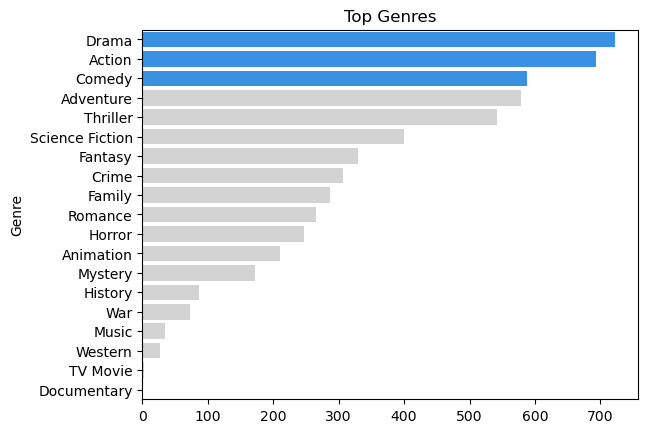

In [25]:
#get the value counts of genres 
top_genres = df_exploded['genre_actual'].value_counts()

#custom color for chart
custom_colors = ['dodgerblue'] * 3 + ['lightgrey'] * (len(top_genres) - 3)

#Horizontal bar chart for top genres
sns.barplot(y = top_genres.index, x = top_genres.values, palette = custom_colors, hue = top_genres.index )
plt.ylabel('Genre')
plt.title('Top Genres')
plt.show()

### More popular movies were released in the 2010s

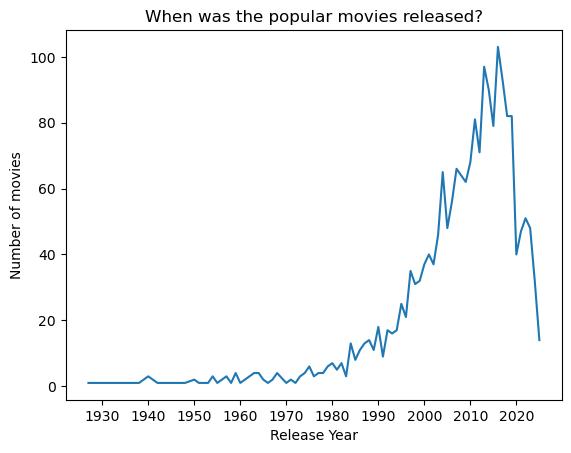

In [26]:
#Plotting a line plot of movie release year
movies_per_year = df_clean['release_year'].value_counts().sort_index()
sns.lineplot(x=movies_per_year.index,y=movies_per_year.values)
plt.xticks(range(1930,2025,10))
plt.title('When was the popular movies released?')
plt.xlabel("Release Year")
plt.ylabel("Number of movies")
plt.show()

In [27]:
#Top 10 release years
df_clean['release_year'].value_counts().head(10)

release_year
2016    103
2013     97
2017     93
2014     90
2019     82
2018     82
2011     81
2015     79
2012     71
2010     68
Name: count, dtype: int64

### Budget is less important

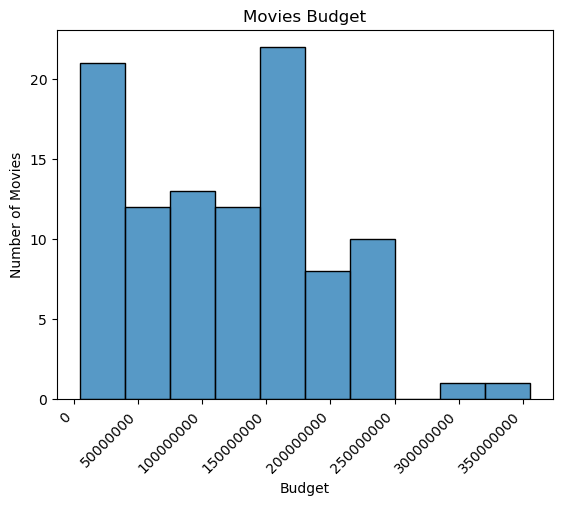

In [28]:
#Plotting the budgets into histograms
sns.histplot(data = df_with_detail, x = 'budget',bins=10)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation = 45, ha='right')
plt.ylabel("Number of Movies")
plt.xlabel("Budget")
plt.title("Movies Budget")
plt.show()

## Question 2: Does having a higher budget lead to higher revenue?

### Movies with higher budget does tend to get higher revenue

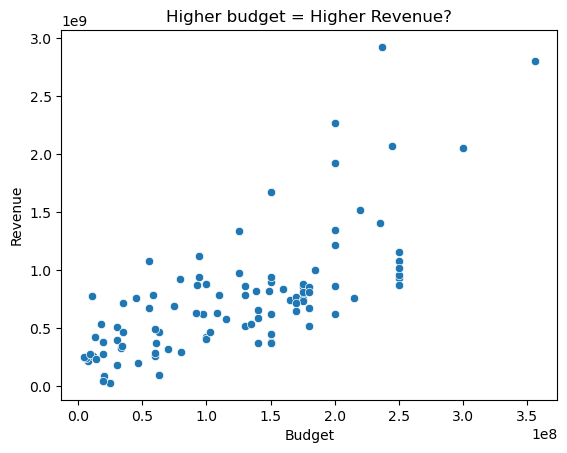

In [29]:
#plotting budget and revenue
sns.scatterplot(x= df_with_detail['budget'],y=df_with_detail['revenue'])
plt.ylabel("Revenue")
plt.xlabel("Budget")
plt.title("Higher budget = Higher Revenue?")
plt.show()

In [30]:
#Checking the correlation
df_with_detail[['budget','revenue']].corr()

,budget,revenue
budget,1.000000,0.708084
revenue,0.708084,1.000000


### Hypothesis Testing

Null Hypothesis: Revenue of high budget movies = Revenue of low budget movies  
Alternate Hypothesis: Revenue of high budget movies > Revenue of low budget movies  
Significance level: 0.05

In [31]:
# Separate into two datasets, one above median budget and one below.
median_budget = df_with_detail['budget'].median()
high_budget_rev = df_with_detail[df_with_detail['budget'] > median_budget]['revenue']
low_budget_rev = df_with_detail[df_with_detail['budget'] <= median_budget]['revenue']

# Two sample t test
t_stat, p_value = stats.ttest_ind(high_budget_rev, low_budget_rev, alternative='greater',equal_var=False)

In [32]:
#Print
print(f"p_value = {p_value} \nReject the Null hypothesis!")

p_value = 2.722878159867607e-07 
Reject the Null hypothesis!


## Question 3: Does having a higher budget lead to higher ratings?

### Money doesn't buy quality

In [33]:
#New dataframe with just budget and vote information
df_q3 = df_with_detail[['budget','vote_average','vote_count']]

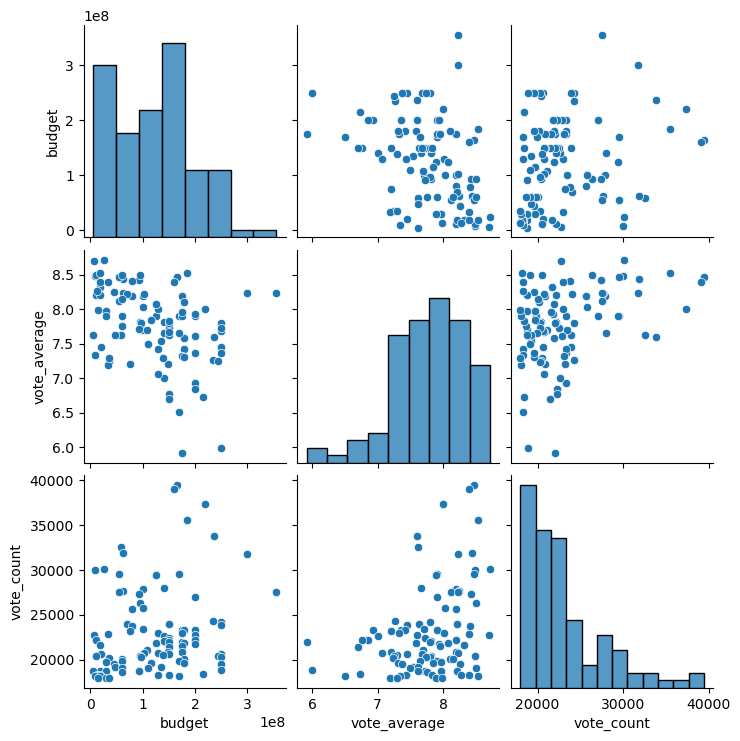

In [34]:
#using pairplot to show scatterplots of each variable
sns.pairplot(df_q3)
plt.show()

In [35]:
#Checking the correlation
df_q3.corr()

,budget,vote_average,vote_count
budget,1.000000,-0.379926,0.231409
vote_average,-0.379926,1.000000,0.353172
vote_count,0.231409,0.353172,1.000000


## Question 4. Does popularity equal higher ratings?

### Weak tendency of popular movies to be also highly rated

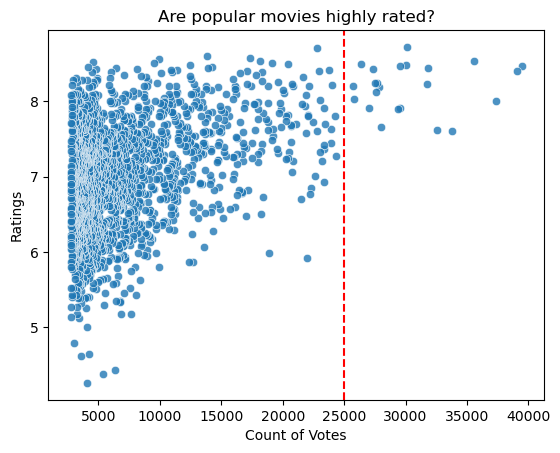

In [36]:
#Vote count vs rating
sns.scatterplot(x= df_clean['vote_count'],y = df_clean['vote_average'],alpha=.8)

#horizontal line through the mean
#mean = df['vote_average'].mean()
#plt.axhline(mean,color='red',linestyle='--')

plt.axvline(25000,color='red',linestyle='--')

plt.title("Are popular movies highly rated?")
plt.ylabel("Ratings")
plt.xlabel("Count of Votes")
plt.show()

In [37]:
#Showing correlation
df_clean[['vote_count','vote_average']].corr()

,vote_count,vote_average
vote_count,1.000000,0.387924
vote_average,0.387924,1.000000


## Question 5: Do newer movies outperform older movies?
 

### Ratings is in a downward trend but could be because of bias

In [38]:
df_clean['decade'].value_counts()

decade
2010    846
2000    521
2020    232
1990    221
1980     92
1970     34
1960     23
1950     17
1940      9
1930      4
1920      1
Name: count, dtype: int64

In [39]:
#Adding a new column that group all the <1980 movies and leave everything the same
df_clean['decade_label'] = np.where(df_clean['decade'] < 1980, 'Pre-1980s', df_clean['decade'].astype(str) + 's') 

#custom x axis order
x_order = ['Pre-1980s', '1980s', '1990s', '2000s', '2010s', '2020s']

# Converting the column into categorical to have order
df_clean['decade_label'] = pd.Categorical(df_clean['decade_label'], categories= x_order, ordered=True)

In [40]:
#Grouping by decade label and aggregating using mean of vote average
df_q5 = df_clean.groupby('decade_label').agg(
    avg_rating=('vote_average', 'mean')
).reset_index()

#Sort using the decade label column
df_q5 = df_q5.sort_values('decade_label').reset_index(drop=True)

C:\Users\pancr\AppData\Local\Temp\ipykernel_33448\2517130964.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_q5 = df_clean.groupby('decade_label').agg(


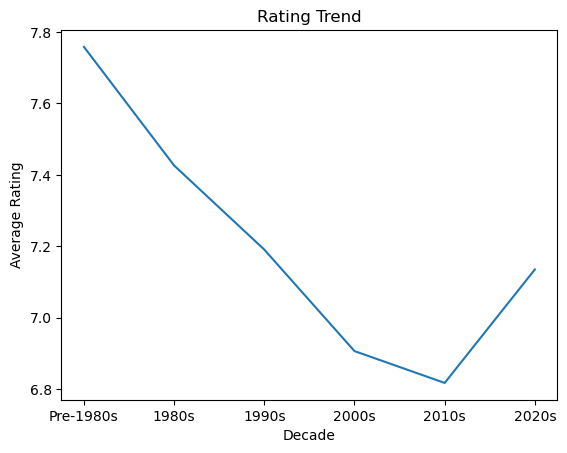

In [41]:
#Showing the trend of the rating
sns.lineplot(x=df_q5['decade_label'],y=df_q5['avg_rating'])
plt.ylabel("Average Rating")
plt.xlabel("Decade")
plt.title("Rating Trend")
plt.show()

In [42]:
#To see the values
df_q5

,decade_label,avg_rating
0,Pre-1980s,7.758034
1,1980s,7.426120
2,1990s,7.190656
3,2000s,6.906628
4,2010s,6.817543
5,2020s,7.135164


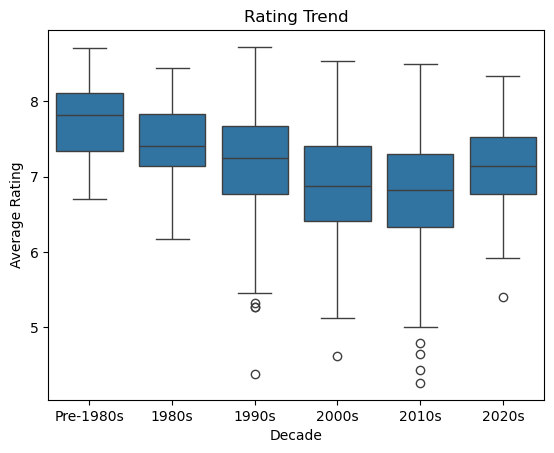

In [43]:
#Similar idea but using boxplot
sns.boxplot(x=df_clean['decade_label'],y=df_clean['vote_average'])
plt.ylabel("Average Rating")
plt.xlabel("Decade")
plt.title("Rating Trend")
plt.show()

## Question 6: Are movies getting longer over time?

### The top 100 movies runtimes stayed relatively the same

In [44]:
#Merge detail dataframe with general dataframe to get decade information
df_q6 = df_with_detail[['id', 'runtime']].merge(df_clean, on='id')

In [45]:
#Top 5 movies by runtime
df_q6.sort_values(by='runtime',ascending=False).head()

,id,runtime,genre_ids,title,original_language,original_title,overview,popularity,release_date,vote_average,vote_count,release_year,decade,decade_label
20,122,201,"[12, 14, 28]",The Lord of the Rings: The Return of the King,en,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,31.1857,2003-12-17,8.496,26353,2003,2000,2000s
19,597,194,"[18, 10749]",Titanic,en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,34.0193,1997-12-18,7.902,27015,1997,1990,1990s
81,497,189,"[14, 18, 80]",The Green Mile,en,The Green Mile,A supernatural tale set on death row in a Sout...,24.1278,1999-12-10,8.504,19101,1999,1990,1990s
17,299534,181,"[12, 878, 28]",Avengers: Endgame,en,Avengers: Endgame,After the devastating events of Avengers: Infi...,42.2819,2019-04-24,8.234,27530,2019,2010,2010s
21,106646,180,"[80, 18, 35]",The Wolf of Wall Street,en,The Wolf of Wall Street,A New York stockbroker refuses to cooperate in...,23.0711,2013-12-25,8.027,25761,2013,2010,2010s


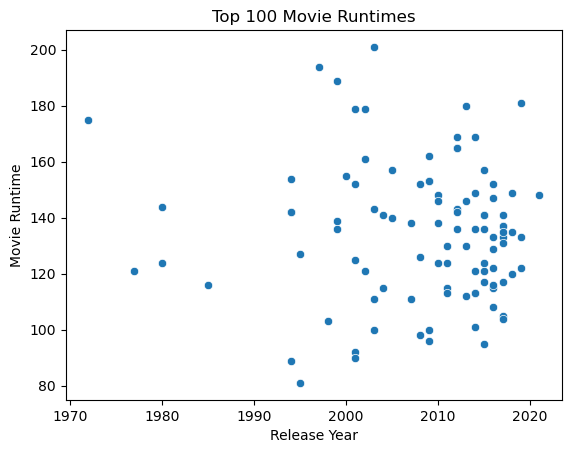

In [46]:
#Plotting release year vs runtime
sns.scatterplot(x=df_q6['release_year'],y=df_q6['runtime'])
plt.xlabel("Release Year")
plt.ylabel("Movie Runtime")
plt.title("Top 100 Movie Runtimes")
plt.show()

In [47]:
#Checking correlation
df_q6[['runtime','release_year']].corr()

,runtime,release_year
runtime,1.000000,-0.063181
release_year,-0.063181,1.000000


### Hypothesis Testing: Are 2010s movies longer than 2000s?

Null Hypothesis: 2010s movies are the same length as 2000s movies  
Alternate Hypothesis: 2010s movies are longer than 2000s movies  
Significane Level: 0.05

In [48]:
#Getting the 2010s and 2000s movies
movie2010s = df_q6[df_q6['decade'] == 2010]['runtime']
movie2000s = df_q6[df_q6['decade'] == 2000]['runtime']

In [49]:
#one sided t-test 2 sample
t_test, p_value = stats.ttest_ind(movie2010s, movie2000s,alternative="greater",equal_var = False)

In [50]:
print(f"p_value: {p_value} \nDon't reject the null hypothesis")

p_value: 0.62230991081894 
Don't reject the null hypothesis


#### 2010s movies are not longer than 2000s movies